In [70]:
import numpy as np
from numpy import sin, cos

In [71]:
def rotate_z(theta):
    col1 = [cos(theta), sin(theta), 0]
    col2 = [-sin(theta), cos(theta), 0]
    col3 = [0, 0, 1]
    return np.array([col1, col2, col3]).transpose()


In [72]:
def rotate_y(phi):
    col1 = [cos(phi), 0, -sin(phi)]
    col2 = [0, 1, 0]
    col3 = [sin(phi), 0, cos(phi)]
    return np.array([col1, col2, col3]).transpose()

In [73]:
phi = np.pi/3
theta = np.pi/2
v = np.array([0, 0, 1])
Ry = rotate_y(phi)
Rz = rotate_z(theta)

Rz @ Ry @ v



array([5.30287619e-17, 8.66025404e-01, 5.00000000e-01])

In [74]:
r = 0.3
R = 1
U = np.linspace(0,2*np.pi,100)
V = U
donut = np.array([[cos(u)*(R+r*cos(v)),
                   sin(u)*(R+r*cos(v)),
                   r*sin(v)] for u in U for v in V]).transpose()
donut

array([[ 1.30000000e+00,  1.29939600e+00,  1.29758644e+00, ...,
         1.29758644e+00,  1.29939600e+00,  1.30000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
        -3.17817017e-16, -3.18260231e-16, -3.18408168e-16],
       [ 0.00000000e+00,  1.90271759e-02,  3.79777361e-02, ...,
        -3.79777361e-02, -1.90271759e-02, -7.34788079e-17]],
      shape=(3, 10000))

In [75]:
phi = 1
theta = 2
transform = rotate_z(theta) @ rotate_y(phi)
dount_r = transform @ donut
np.shape(dount_r)

(3, 10000)

In [76]:
big_ring = R*np.array([[cos(u),sin(u),0] for u in U for v in V]).transpose()
normal = donut - big_ring
normal = normal/r

In [77]:
np.linalg.norm(normal,axis = 1)

array([50.5       , 49.99749994, 70.3562364 ])

In [78]:
radius = 1.3*(R + r)
res_x = 32
res_y = 16
x_line = np.linspace(-radius, radius, res_x)
y_line = np.linspace(-radius, radius, res_y)
pixils = np.stack(np.meshgrid(x_line,y_line), axis=2)

In [79]:
np.shape(pixils)

(16, 32, 2)

In [80]:
pixil_len_x = x_line[1] - x_line[0]
pixil_len_y = y_line[1] - y_line[0]
def calculate_brightness_pixil(transform):
    screen = np.zeros([res_y, res_x])
    _donut = transform @ donut
    _normal = transform @ normal
    brightness_3d = _normal[2,:] + 1
    def in_pixl_widow(points, pixil)->bool:
        x, y = pixil
        return (x-pixil_len_x<points[1,:]) & (points[1,:]<x+pixil_len_x) & (y-pixil_len_y<points[2,:]) & (points[2,:]<y+pixil_len_y)
    for i in range(res_y):
        for j in range(res_x):
            mask = in_pixl_widow(_donut, pixils[i][j])
            x_vals = _donut[0,:][mask]
            screen[i][j] = brightness_3d[mask][np.argmax(x_vals)] if x_vals.size > 0 else 0
    return screen


In [81]:
ASCII_BRIGHTNESS = ".,-~:;=!*$$###@"
def show_donut(transform):
    screen = calculate_brightness_pixil(transform)
    scaled = np.zeros_like(screen)
    visible = screen > 0
    
    if np.any(visible):
        lo = screen[visible].min()
        hi = screen[visible].max()
        scaled[visible] = (screen[visible] - lo) / (hi - lo)
        
    # 定義 ANSI 顏色代碼
    PINK_DARK = "\033[38;5;168m"   # 暗部草莓紅
    PINK_LIGHT = "\033[38;5;211m"  # 亮部草莓粉紅
    WHITE_GLOW = "\033[38;5;231m"  # 糖霜反光白
    RESET = "\033[0m"              # 重設顏色
    
    rows = []
    for row in scaled[::-1]:
        chars = []
        for value in row:
            if value <= 0:
                chars.append(" ")
            else:
                # 依據亮度決定字元
                idx = min(len(ASCII_BRIGHTNESS)-1 , int(value * (len(ASCII_BRIGHTNESS) - 1)))
                char = ASCII_BRIGHTNESS[idx]
                
                # 依據亮度上色（value 範圍是 0~1）
                if value < 0.4:
                    # 暗部：深粉紅
                    chars.append(f"{PINK_DARK}{char}{RESET}")
                elif value < 0.8:
                    # 亮部：一般草莓粉
                    chars.append(f"{PINK_LIGHT}{char}{RESET}")
                else:
                    # 頂部反光：白色糖霜感！
                    chars.append(f"{WHITE_GLOW}{char}{RESET}")
                    
        rows.append("".join(chars))
        
    donut_frame = "\n".join(rows)
    return donut_frame

In [82]:
transform = rotate_z(np.pi/6) @ rotate_y(np.pi/3)
X, Y, Z =transform @ donut
print(show_donut(transform))

                                
                                
        ######$$$###            
      ####$$*!!===!*$$#         
    $#####$*=!!===!=!=$$#       
    $$$$$$$===;:;;===*$$$$      
    *$$$$$$$~. .,~:==*$$$$$     
    =!*$$$$$      -:=$$$$$$$    
    =!!!***$$#      $####$$*    
     =!!====!*$$##@#####$$!!    
     ~:;=====!==!********!=!    
       ~~;===!==!==!=!***!=     
         --~::;;===!=!!=::      
            .,,,---~~--,        
                                
                                


In [83]:
from IPython.display import clear_output
import time
angle = 0.0
while True:
    clear_output(wait=True)
    print(show_donut(rotate_z(angle) @ rotate_y(angle / 2)))
    angle += 0.08
    time.sleep(0.03)

                                
                                
        ####@                   
      !*$$$#####                
      ;*=**$$$$###              
      ;*=;==***$$$#             
       -:;===!!!!!*$$           
        ..-:=!!=!!=!!$$         
         ,---:;====!=!!*        
           -~;-~:;;;=!!==       
             :;=-~~:::;===      
              -;!,,----~:=      
                ,;-..,,,-:      
                   ....         
                                
                                


KeyboardInterrupt: 

動畫已停止。


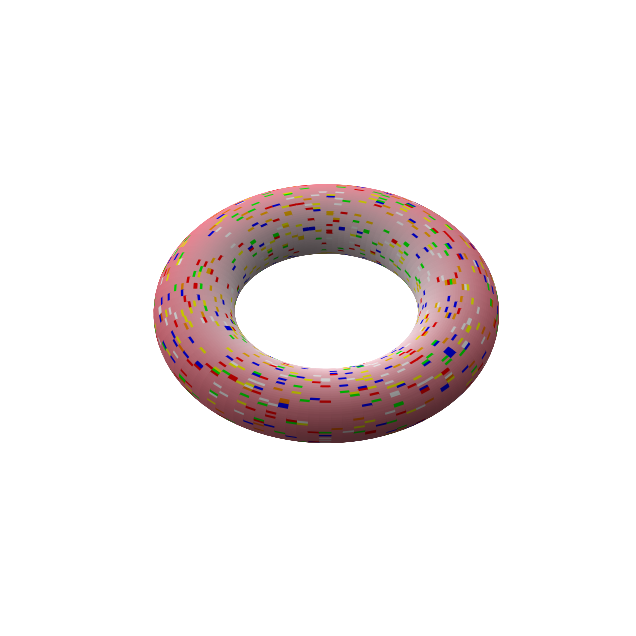

In [ ]:
import numpy as np
from numpy import sin, cos
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output, display
import time

# 啟用 Jupyter Notebook 的內嵌繪圖模式
%matplotlib inline

# --- 1. 設定甜甜圈幾何參數 ---
r = 0.3  # 小圓半徑（管子粗細）
R = 1.0  # 大圓半徑（甜甜圈中心到管子中心的距離）

# 建立 3D 網格（解析度設為 100x100 讓表面更平滑）
U_res, V_res = 100, 100
u = np.linspace(0, 2 * np.pi, U_res)
v = np.linspace(0, 2 * np.pi, V_res)
u, v = np.meshgrid(u, v)

# 根據甜甜圈參數方程計算 3D 座標
x_base = (R + r * cos(v)) * cos(u)
y_base = (R + r * cos(v)) * sin(u)
z_base = r * sin(v)

# --- 2. 設計草莓糖霜與五彩糖珠顏色 ---
# 建立一個基礎顏色矩陣，預設填滿草莓粉紅色 [紅, 綠, 藍]
donut_color = np.ones((U_res, V_res, 3)) * [255, 182, 193] / 255.0

# 隨機撒上糖珠
np.random.seed(42)  # 固定隨機種子，讓糖珠位置在旋轉時不會亂跳
sprinkle_coverage = 0.15  # 糖珠密度（15% 的表面積）
sprinkle_mask = np.random.rand(U_res, V_res) < sprinkle_coverage

# 糖珠顏色池（白、紅、綠、藍、黃、橘）
sprinkle_colors_pool = np.array([
    [255, 255, 255], [255, 0, 0], [0, 255, 0], 
    [0, 0, 255], [255, 255, 0], [255, 165, 0]
]) / 255.0

# 將隨機顏色填入有糖珠的遮罩位置
num_sprinkles = sprinkle_mask.sum()
random_colors = sprinkle_colors_pool[np.random.choice(len(sprinkle_colors_pool), num_sprinkles)]
donut_color[sprinkle_mask] = random_colors

# --- 3. 初始化畫布與光源 ---
fig = plt.figure(figsize=(8, 8))
ls = LightSource(azdeg=135, altdeg=45)  # 設定 3D 光源角度，產生陰影與反光

# --- 4. 動畫渲染迴圈 ---
angle = 0.0
try:
    while True:
        clear_output(wait=True)
        fig.clear()
        
        # 建立 3D 繪圖區
        ax = fig.add_subplot(111, projection='3d')
        
        # 透過改變視角（azim）來達到甜甜圈旋轉的效果
        ax.view_init(elev=45, azim=angle)
        
        # 計算光影與色彩的混合（讓粉紅色表面有立體光澤感）
        #  修正後的安全寫法
        rgba_donut = ls.shade_rgb(rgb=donut_color, elevation=z_base, blend_mode='soft')
        
        # 繪製立體表面
        surf = ax.plot_surface(x_base, y_base, z_base, facecolors=rgba_donut,
                               rstride=1, cstride=1, antialiased=True)
        
        # 固定 3D 軸範圍，避免旋轉時畫面忽大忽小
        ax.set_xlim(-1.5, 1.5)
        ax.set_ylim(-1.5, 1.5)
        ax.set_zlim(-1.5, 1.5)
        ax.axis('off')  # 隱藏難看的座標軸線
        
        display(fig)
        
        angle += 8.0  # 每次旋轉的角度
        time.sleep(0.01)  # 動畫停頓時間
        
except KeyboardInterrupt:
    print("動畫已停止。")

In [ ]:
import numpy as np
from numpy import sin, cos
from IPython.display import clear_output
import time

# --- 1. 初始化參數與畫面大小 ---
res_x, res_y = 60, 30          # 提高一點解析度，畫面更細緻
pixel_aspect = 2.0             # 修正字元寬高比（防止甜甜圈被垂直拉長）

r, R = 0.4, 1.0                # 甜甜圈半徑
U = np.linspace(0, 2 * np.pi, 80)
V = np.linspace(0, 2 * np.pi, 80)

# 生成點雲與法向量
# donut_pts 網格形狀 (3, 6400)，normal_pts 網格形狀 (3, 6400)
donut_pts = np.array([[cos(u)*(R + r*cos(v)), sin(u)*(R + r*cos(v)), r*sin(v)] for u in U for v in V]).T
normal_pts = np.array([[cos(u)*cos(v), sin(u)*cos(v), sin(v)] for u in U for v in V]).T

# --- 2. 隨機撒上五彩糖珠 (Sprinkles) ---
np.random.seed(42)
# 為 6400 個點隨機分配顏色類型：0=粉紅, 1=白, 2=紅, 3=綠, 4=黃, 5=藍
# 讓粉紅色佔 80%，其他糖珠顏色各佔一些
color_indices = np.random.choice(
    [0, 1, 2, 3, 4, 5], 
    size=donut_pts.shape[1], 
    p=[0.75, 0.05, 0.05, 0.05, 0.05, 0.05]
)

# 定義 256 色 ANSI 顏色碼
ANSI_COLORS = {
    0: "\033[38;5;211m",  # 草莓粉紅
    1: "\033[38;5;231m",  # 糖珠：白
    2: "\033[38;5;196m",  # 糖珠：紅
    3: "\033[38;5;46m",   # 糖珠：綠
    4: "\033[38;5;226m",  # 糖珠：黃
    5: "\033[38;5;51m",   # 糖珠：藍
}
RESET = "\033[0m"
ASCII_BRIGHTNESS = ".,-~:;=!*#$@"  # 亮度字符 (共 12 階)

# 旋轉矩陣函式
def get_rotation(pitch, roll):
    # pitch (繞Y軸), roll (繞Z軸)
    R_y = np.array([[cos(pitch), 0, -sin(pitch)], [0, 1, 0], [sin(pitch), 0, cos(pitch)]])
    R_z = np.array([[cos(roll), sin(roll), 0], [-sin(roll), cos(roll), 0], [0, 0, 1]])
    return R_z @ R_y

# --- 3. 動畫渲染迴圈 ---
angle = 0.0
try:
    while True:
        # 初始化畫布 (儲存字元) 與 深度緩衝區 (Z-buffer, 初始化為極小值)
        screen = np.full((res_y, res_x), " ", dtype=object)
        z_buffer = np.full((res_y, res_x), -100.0)
        
        # 計算當前旋轉
        R_mat = get_rotation(angle, angle * 0.5)
        rot_donut = R_mat @ donut_pts
        rot_normal = R_mat @ normal_pts
        
        # 投影到 2D 螢幕 (使用 Z 軸作為深度，X 和 Y 作為螢幕座標)
        # 加上位移避免負數，並縮放到畫布大小
        screen_x = ((rot_donut[0, :] * 1.3 + 2.0) * (res_x / 4.0)).astype(int)
        screen_y = ((rot_donut[1, :] * 1.3 * pixel_aspect + 2.0) * (res_y / 4.0)).astype(int)
        
        # 計算環境光（假設光源從前上方 [0, -1, 1] 照過來）
        # 內積計算亮度
        light_vec = np.array([0, -0.707, 0.707])
        brightness = rot_normal.T @ light_vec
        
        # 向量化遍歷所有點，填入 Z-buffer
        for k in range(rot_donut.shape[1]):
            x, y = screen_x[k], screen_y[k]
            # 確保點在螢幕範圍內
            if 0 <= x < res_x and 0 <= y < res_y:
                z = rot_donut[2, k]  # Z 軸作為深度
                if z > z_buffer[y, x]:  # 如果當前的點比原本的點更靠前
                    z_buffer[y, x] = z
                    
                    # 計算對應的亮度字元
                    b_idx = int((brightness[k] + 1) / 2 * (len(ASCII_BRIGHTNESS) - 1))
                    b_idx = max(0, min(len(ASCII_BRIGHTNESS) - 1, b_idx))
                    char = ASCII_BRIGHTNESS[b_idx]
                    
                    # 著色：加上 ANSI 顏色碼
                    color_code = ANSI_COLORS[color_indices[k]]
                    screen[y, x] = f"{color_code}{char}{RESET}"
        
        # 組合畫面並列印
        output = []
        for row in screen[::-1]:  # 垂直翻轉符合座標系
            output.append("".join(row))
        
        clear_output(wait=True)
        print("\n".join(output))
        
        angle += 0.08
        time.sleep(0.03)

except KeyboardInterrupt:
    print("動畫已停止。")

       :;;=,!!,*,*-## #$$$$$$$$$$$$$$####*,**!! ==;;:       
       - ,=!,!*,*-####$$$$$$$$$$$$$$$$###-*-**!!= ==;:      
      :;==!,!* * *###$$$$$$$$$$$$$$$$$####~***!,!!=,-~~     
     :;=,, !*,***## #$$$$$$$$$$$$$$$$$####*** *!,,!==;;     
     : -=!! -****####$$$$$$$$$$$$$$$$#####**** !!!, --~~    
    ;;==!!,!****######$$$#         ########*****-!!!==;;    
    : -- !!******#######            *###********! -- --:    
   :;==!!!!-*****#*####               *#*********!!!!==;;   
   : -- --************                 ********* !!!!!= :   
   ;==!!!!***********                  !!********!  -- =;   
   ; !!!!!**~*******                    !!!!!*~**!!!!!!=:   
   ===---  ***!!!!!!                     !!!!!!~~  --- ==   
  ;;!!!!!!**!!!:!!!                      =!!!!!!!!!!!!!! ;  
   == ---!!!!!!!!==                      ==!!!!!!***!  ==;  
  ; !!!!! -~~~!!===                      ;==!!!!!   ~!!! ;  
  :=!  ***!!!!!!==;                      ;==:~~~!****  !!=  
  = !!!~~ !!!!!===;     